|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>The GPU<h1>|
|<h2>Lecture:</h2>|<h1><b>A different kind of machine<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# Find the repo root. The directory you start from does not matter.
import sys
import time
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# A machine built for one kind of work

A CPU has a small number of fast cores. Each core runs its own program, with
branches, and it is good at work that changes at each step.

A **GPU** is a different machine. It runs thousands of small **threads** at
the same time, and they all run the same instructions on different data. If
you know SIMD, a GPU is a very wide SIMD machine.

In GPU words, the CPU and its memory are the **host**. The GPU and its memory
are the **device**. This notebook measures the device: what it is fast at,
and what it waits for.

In [2]:
properties = torch.cuda.get_device_properties(0)
threads_per_sm = properties.max_threads_per_multi_processor
print(f'GPU:                         {properties.name}')
print(f'SMs (the cores of the GPU):  {properties.multi_processor_count}')
print(f'threads that each SM holds:  {threads_per_sm:,}')
print(f'threads resident at one time: {properties.multi_processor_count * threads_per_sm:,}')
print(f'GPU memory:                  {properties.total_memory / 2**30:.1f} GiB')
print(f'\nCPU cores on the host:       {__import__("os").cpu_count()}')

GPU:                         NVIDIA GeForce RTX 4080 Laptop GPU
SMs (the cores of the GPU):  58
threads that each SM holds:  1,536
threads resident at one time: 89,088
GPU memory:                  11.6 GiB

CPU cores on the host:       32


An **SM**, streaming multiprocessor, is one core of the GPU. Each SM holds
many threads, and it switches between them at no cost. The GPU hides the wait
for memory this way: while some threads wait, others run.

### Step 1: the same work, three ways

Add two vectors of 16 million numbers. Do it in a Python loop, with NumPy on
the CPU, and with torch on the GPU.

In [3]:
NUM_VALUES = 2**24
host_a = np.random.rand(NUM_VALUES).astype(np.float32)
host_b = np.random.rand(NUM_VALUES).astype(np.float32)

def seconds(function, repeats=3):
  """The best wall time of `repeats` calls."""
  best = float('inf')
  for _ in range(repeats):
    start = time.perf_counter()
    function()
    best = min(best, time.perf_counter() - start)
  return best

SAMPLE = 100_000                  # a Python loop is too slow for all of them
python_ms = seconds(lambda: [x + y for x, y in zip(host_a[:SAMPLE], host_b[:SAMPLE])], 1)
python_ms *= 1e3 * NUM_VALUES / SAMPLE
numpy_ms = 1e3 * seconds(lambda: host_a + host_b)

device_a = torch.from_numpy(host_a).cuda()
device_b = torch.from_numpy(host_b).cuda()
gpu_ms = cudalib.bench_ms(lambda: device_a + device_b)
copy_ms = cudalib.bench_ms(lambda: torch.from_numpy(host_a).cuda(), iters=5, warmup=2)

print(f'Python loop:  {python_ms:9.1f} ms   (estimated from {SAMPLE:,} values)')
print(f'NumPy, CPU:   {numpy_ms:9.2f} ms')
print(f'torch, GPU:   {gpu_ms:9.3f} ms   ({numpy_ms / gpu_ms:.0f}x faster than NumPy)')
print(f'\ncopy ONE input from host to device: {copy_ms:.2f} ms  ({copy_ms / gpu_ms:.0f}x the add)')

Python loop:     1013.9 ms   (estimated from 100,000 values)
NumPy, CPU:        9.10 ms
torch, GPU:       0.666 ms   (14x faster than NumPy)

copy ONE input from host to device: 6.10 ms  (9x the add)


Look at the last line. To copy the data to the GPU costs more than the add.
The link between the host and the device, the **interconnect**, is slow
compared with the memory of the GPU. So an inference engine keeps the weights
and all its state on the device, and never moves them.

### Step 2: what does the GPU add wait for?

Count what the add does for each number. It reads two numbers of 4 bytes, and
it writes one: 12 bytes. It does one addition: one **FLOP**, one
floating-point operation.

The memory of the GPU is **HBM**, or VRAM. Its speed is its **bandwidth**: the
bytes for each second that it can move. Compare the bytes for each second of
the add with the bandwidth that `cudalib` measures on this card.

In [4]:
PEAK_BANDWIDTH = cudalib.peak_bandwidth() * 1e9     # bytes/s, measured on this card
PEAK_FLOPS = cudalib.matmul_flops()                  # FLOP/s of a bf16 matmul, measured
print(f'memory bandwidth: {PEAK_BANDWIDTH/1e9:6.0f} GB/s')
print(f'arithmetic:       {PEAK_FLOPS/1e12:6.1f} TFLOP/s')

add_bytes = 12 * NUM_VALUES
add_bandwidth = add_bytes / (gpu_ms / 1e3)
print(f'\nthe add moves {add_bandwidth/1e9:.0f} GB/s: {100 * add_bandwidth / PEAK_BANDWIDTH:.0f}% of the bandwidth')
print(f'the add does  {NUM_VALUES / (gpu_ms / 1e3) / 1e12:.3f} TFLOP/s: '
      f'{100 * NUM_VALUES / (gpu_ms / 1e3) / PEAK_FLOPS:.2f}% of the arithmetic')

memory bandwidth:    335 GB/s
arithmetic:         52.7 TFLOP/s

the add moves 302 GB/s: 90% of the bandwidth
the add does  0.025 TFLOP/s: 0.05% of the arithmetic


The add uses almost all the bandwidth, and almost none of the arithmetic. It
waits for memory. That is **memory-bound** work. A faster memory makes it
faster. More arithmetic units do not.

### Step 3: the ratio that decides

Divide the arithmetic speed by the memory speed. The result is the number of
FLOPs that the GPU can do in the time that it reads one byte. This number is
the **ridge point** of the card.

The FLOPs that a piece of work does for each byte that it reads is its
**arithmetic intensity**. If the intensity is below the ridge point, the work
waits for memory. If it is above, the work waits for arithmetic: it is
**compute-bound**.

In [5]:
ridge = PEAK_FLOPS / PEAK_BANDWIDTH
print(f'ridge point of this card: {ridge:.0f} FLOP for each byte')
print(f'the vector add:           {1/12:.3f} FLOP for each byte')
print(f'\nthe add would need {ridge * 12:,.0f}x more arithmetic for each byte to use the whole GPU')

ridge point of this card: 157 FLOP for each byte
the vector add:           0.083 FLOP for each byte

the add would need 1,886x more arithmetic for each byte to use the whole GPU


### Step 4: three shapes of work

A model does three kinds of arithmetic. Measure each one, and put it on one
plot.

- The vector add: 1/12 FLOP for each byte.
- A **GEMV**: a matrix times a vector. The GPU reads each weight once and uses
  it once: about 1 FLOP for each byte in bf16. A model does this for ONE token.
- A **matmul**: a matrix times a matrix. The GPU reads each weight once and
  uses it for each row of the other matrix. A model does this for MANY tokens
  at the same time. The tokens can be a long prompt, or a **batch**: a group
  of sequences that the GPU processes together.

The plot is a **roofline**. The slope on the left is the bandwidth. The flat
line on the right is the arithmetic. Each point sits under the roof.

vector add          0.08 FLOP/byte     0.03 TFLOP/s
GEMV (1 token)      1.00 FLOP/byte     0.37 TFLOP/s


matmul           2730.67 FLOP/byte    50.45 TFLOP/s


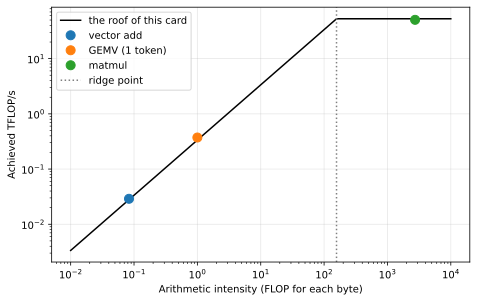

In [6]:
SIZE = 8192          # 128 MB of bf16: larger than the L2 cache of any GPU
matrix = torch.randn(SIZE, SIZE, device='cuda', dtype=torch.bfloat16)
vector = torch.randn(SIZE, 1, device='cuda', dtype=torch.bfloat16)
workloads = {
  #                 (function,                  FLOP,             bytes)
  'vector add':     (lambda: device_a + device_b, NUM_VALUES,       12 * NUM_VALUES),
  'GEMV (1 token)': (lambda: matrix @ vector,     2 * SIZE * SIZE,  2 * SIZE * SIZE),
  'matmul':         (lambda: matrix @ matrix,     2 * SIZE**3,      3 * 2 * SIZE * SIZE),
}

intensities = np.logspace(-2, 4, 200)
plt.figure(figsize=(7.5, 4.6))
plt.plot(intensities, np.minimum(PEAK_FLOPS, intensities * PEAK_BANDWIDTH) / 1e12, 'k-',
         label='the roof of this card')
for name, (function, flops, num_bytes) in workloads.items():
  milliseconds = cudalib.bench_ms(function, best_of=3)
  achieved = flops / (milliseconds / 1e3)
  plt.plot(flops / num_bytes, achieved / 1e12, 'o', markersize=9, label=name)
  print(f'{name:<15} {flops/num_bytes:8.2f} FLOP/byte  {achieved/1e12:7.2f} TFLOP/s')
plt.axvline(ridge, color='gray', ls=':', label='ridge point')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Arithmetic intensity (FLOP for each byte)')
plt.ylabel('Achieved TFLOP/s')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### What to remember from this notebook

- A **GPU** runs thousands of **threads** on its **SMs**. It is fast at the
  same operation on much data.
- Its memory, **HBM**, has a **bandwidth**. Its arithmetic has a FLOP/s. The
  ratio of the two is the **ridge point**.
- Work below the ridge point is **memory-bound**. Work above it is
  **compute-bound**.
- One token through a model is a chain of GEMVs: far below the ridge point.

That last fact is the start of Part 1. When a model makes one token for one
user, the GPU reads all the weights and does almost no arithmetic on them. The
arithmetic units wait. Most ideas in this course find a way to do more useful
work for each byte that the GPU reads.